# Лабораторная №1. Классификация рукописных цифр (MNIST) методом k ближайших соседей (KNN)

## Цель работы

Изучить принцип работы алгоритма k ближайших соседей (k-Nearest Neighbors, KNN) и применить его для задачи классификации изображений рукописных цифр из датасета MNIST. Оценить качество классификации и исследовать влияние гиперпараметра **K** на точность.

## Краткие теоретические сведения

### Датасет MNIST

MNIST — классический датасет для задач машинного обучения, содержащий 70 000 изображений рукописных цифр от 0 до 9:  

- **60 000** изображений — обучающая выборка;  
- **10 000** изображений — тестовая выборка.  

Каждое изображение имеет размер **28×28 пикселей** (784 признака при развёртке в вектор) и представлено в оттенках серого (значения от 0 до 255). Метка класса — цифра от 0 до 9.

### Алгоритм KNN

KNN — метрический алгоритм классификации, основанный на гипотезе компактности: объекты одного класса располагаются близко друг к другу в пространстве признаков.

**Идея алгоритма:**

1.	Для нового (тестового) объекта вычисляется расстояние до всех объектов обучающей выборки.
2.	Выбираются **K** ближайших соседей.
3.	Класс определяется голосованием: побеждает класс, наиболее часто встречающийся среди соседей.

**Метрика расстояния (евклидова):**

d(x,y) = √(∑^n_(i=1)((x_i -y_i))^2)  
Где n – число признаков (784 для MNIST).

**Важные замечания:**
- Признаки желательно нормализовать (привести к диапазону [0, 1]), так как KNN чувствителен к масштабу.
- Выбор **K** влияет на качество: слишком маленькое **K** → переобучение, слишком большое → недообучение.
- KNN — «ленивый» алгоритм: обучение отсутствует, вся работа происходит на этапе предсказания.

## Постановка задачи

Требуется:
1.	Загрузить датасет MNIST.
2.	Подготовить данные (нормализация, разбиение на обучающую и тестовую выборки).
3.	Реализовать классификатор KNN.
4.	Обучить и протестировать модель.
5.	Оценить качество (accuracy, матрица ошибок).
6.	Исследовать зависимость точности от параметра **K**.
7.	Протестировать алгоритм на своем рисунке (можно нарисовать в paint).

## Ход работы

Импортируем библиотеки pandas для работы с таблицами, numpy для работы с массивами и matplotlib для визуализациии построения графиков

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

Получаем тренировочные и тестовые данные из csv файлов с помощью pandas

In [5]:
PATH = './data'

In [6]:
mnist_train = pd.read_csv(f'{PATH}/mnist_train.csv')
mnist_train.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
mnist_test = pd.read_csv(f'{PATH}/mnist_test.csv')
mnist_test.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Проверим NaN значения

In [237]:
mnist_train.isna().any().sum()

np.int64(0)

In [238]:
mnist_test.isna().any().sum()

np.int64(0)

Разделим данные на numpy массивы из признаков и меток

In [ ]:
def get_features_labels_from_df(df: pd.DataFrame) -> tuple(np.ndarray, np.ndarray):
    features = np.array(df.drop('label', axis=1))
    labels = np.array(df['label'])
    return (features, labels)

In [18]:
features_train, labels_train = get_features_labels_from_df(mnist_train)
features_test, labels_test = get_features_labels_from_df(mnist_test)

Нормализуем признаки

In [ ]:
def get_nomralize_features_func(features: np.ndarray):
    features_min = features.min(axis=0)
    features_max = features.max(axis=0)

    denom = FEATURES_MAX - features_min
    denom = np.where(denom == 0, 1.0, denom)

    def normalize_features(features: np.ndarray) -> np.ndarray:
        return (features - features_min) / denom

    return normalize_features

normalize_features = get_nomralize_features_func(features_train)

In [241]:
features_train_norm = normalize_features(features_train)
features_test_norm = normalize_features(features_test)

np.float64(1.0)

Реализуем классификатор KNN

In [213]:
def knn_algorithm(features_train: np.ndarray, labels_train: np.ndarray):
    # близость (расстояние) между объектом и каждым объектом тренировочной выборки
    get_nearness = lambda obj: np.sqrt(((features_train - obj) ** 2).sum(axis=1))

    def knn(features: np.ndarray, k: int = 1):
        if features.ndim == 1:
            features = features.reshape((-1, features.shape[0]))
        nearness = np.apply_along_axis(get_nearness, axis=1, arr=features)

        # получаем индексы k ближайших соседей
        neighbors_indexes = np.argpartition(nearness, k, axis=1)[:, :k]

        vals, counts = np.unique(labels_train[neighbors_indexes], return_counts=True, axis=1)
        return vals[:, np.argmax(counts)]
    
    return knn

In [ ]:
knn = knn_algorithm(features_train_norm, labels_train)

Реализуем функцию оценки качества модели (accuracy)

In [173]:
def score(labels_pred, labels):
    return labels[labels == labels_pred].size / labels.size

In [170]:
score(knn(features_test_norm), labels_test)

0.9691

Для исследования зависимости точкости от параметра k немного изменим реализацию алгоритма для оптимизации расчетов (чтобы не пересчитывать для каждого значения k)

In [ ]:
def knn_algorithm_k(features_train: np.ndarray, labels_train: np.ndarray):
    # близость (расстояние) между объектом и каждым объектом тренировочной выборки
    get_nearness = lambda obj: np.sqrt(((features_train - obj) ** 2).sum(axis=1))

    def knn(features: np.ndarray):
        # проведем анализ для k = [1, 10]
        k_arr = [k for k in range(1, 11)]

        if features.ndim == 1:
            features = features.reshape((-1, features.shape[0]))
        nearness = np.apply_along_axis(get_nearness, axis=1, arr=features)

        result = []
        for k in k_arr:
            # получаем индексы k ближайших соседей
            neighbors_indexes = np.argpartition(nearness, k, axis=1)[:, :k]
            vals, counts = np.unique(labels_train[neighbors_indexes], return_counts=True, axis=1)
            result.append(vals[:, np.argmax(counts)])
        return result
    
    return knn

In [191]:
knn_k = knn_algorithm_k(features_train_norm, labels_train)
result = knn_k(features_test_norm)

1
2
3
4
5
6
7
8
9
10


Получим точность для каждого значения k

In [192]:
def score_k(labels_pred):
    return score(labels_pred, labels_test)

In [193]:
scores = np.apply_along_axis(score_k, axis=1, arr=np.array(result))
print(scores)

[0.9691 0.9691 0.9664 0.9647 0.9637 0.9605 0.9515 0.9399 0.9517 0.9468]


Визуализируем зависимость на графике

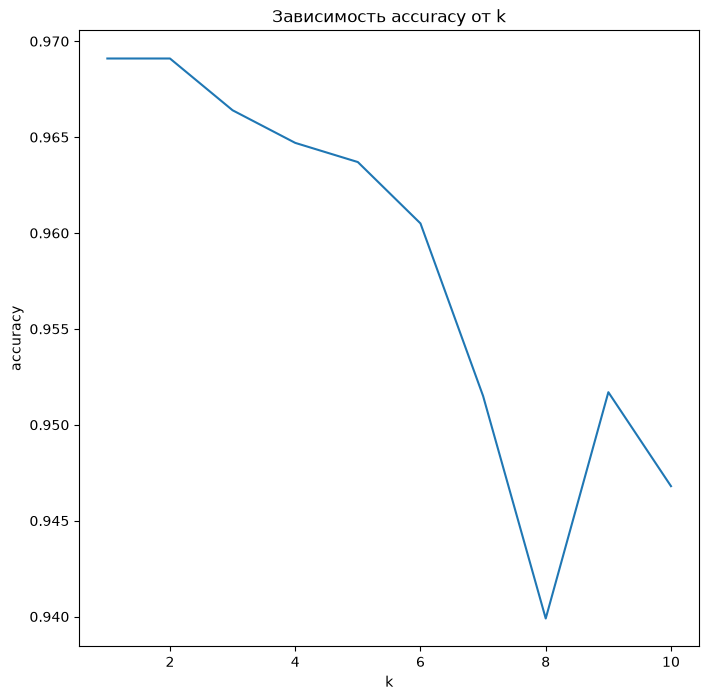

In [235]:
_, ax = plt.subplots(1, 1, figsize=(8,8))
ax.set_title('Зависимость accuracy от k')
ax.plot([k for k in range(1, 11)], scores)
ax.set_ylabel('accuracy')
ax.set_xlabel('k')
plt.show()

Из графика видно, что наивысшая точность у аглоритма при k = [1, 2], поэтому в качестве оптимального значения k выберем k = 1

Протестируем алгоритм на собственном рисунке

In [ ]:
import cv2

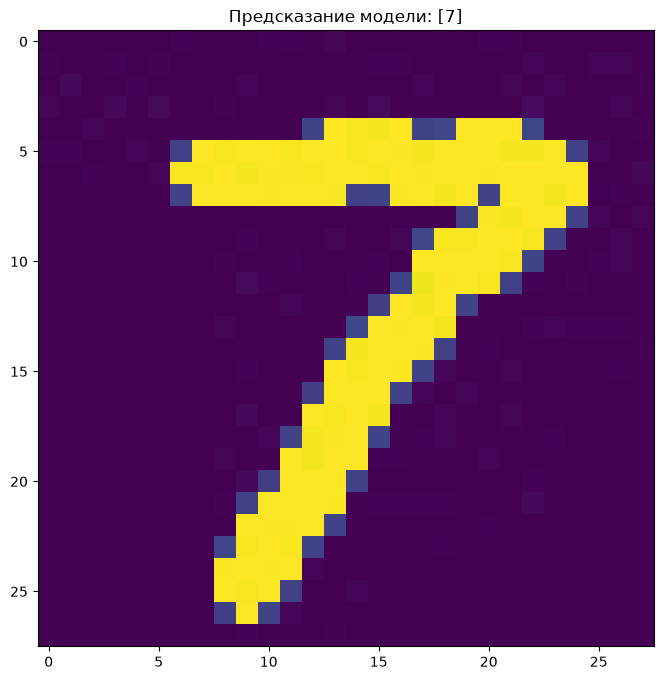

In [234]:
img = cv2.imread(f"{PATH}/images/7.jpg", cv2.IMREAD_GRAYSCALE)
img_v = img.reshape(28*28)
img_norm = normalize_features(img_v)
label_pred = knn(img_norm)
_, ax = plt.subplots(1, 1, figsize=(8,8))
ax.set_title(f'Предсказание модели: {label_pred}')
ax.imshow(img)
plt.show()